<a href="https://colab.research.google.com/github/andilMc/gemmafro-e2b/blob/main/notebooks/04_evaluate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Évaluation (Phase 4)

Correspond à la Phase 4 de `docs/WORKFLOW.md`. Charge l'adaptateur LoRA final produit en Phase 3, génère des réponses sur `Val.csv`, calcule ROUGE-1/ROUGE-L **par langue**, et compare au zero-shot (même modèle, adaptateur désactivé) pour quantifier le gain réel du fine-tuning.

## 1 — Environnement

In [1]:
!pip install -q -U transformers accelerate peft bitsandbytes datasets rouge-score pandas matplotlib

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 151.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 162.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 52.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3

In [2]:
import os
from google.colab import drive

drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/gemmafro-e2b'
PROCESSED_DIR = f'{PROJECT_DIR}/processed_data'
ADAPTER_DIR = f'{PROJECT_DIR}/checkpoints/gemma-4-e2b-lora-final'
assert os.path.isdir(ADAPTER_DIR), "Adaptateur introuvable — exécuter 03_finetune.ipynb jusqu'au bout d'abord."

Mounted at /content/drive


In [4]:
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('HF_TOKEN'))

## 2 — Charger `Val.csv` formaté (Phase 2)

In [5]:
import pandas as pd

val = pd.read_json(f'{PROCESSED_DIR}/val_formatted.jsonl', lines=True)
print(val.shape)
val.head(3)

(6686, 5)


,ID,subset,input,output,prompt_text
0,ID_VL_Aka_Gha_A3B1799D,Aka_Gha,Sɛn na nwomasua ne adwuma nteteeɛ boa akuo a e...,Nhyehyɛeɛ aa ama ne mu so te sɛ senea aborɔfo ...,<bos><|turn>user\nRéponds à la question de san...
1,ID_VL_Aka_Gha_1C80317F,Aka_Gha,Dɛn nti na ɛho hia sɛ mmabun te wɔn nna ne awo...,Nna ne awo hokwan ahorow a wɔte ase no ma mmab...,<bos><|turn>user\nRéponds à la question de san...
2,ID_VL_Aka_Gha_06671AD1,Aka_Gha,Mɛyɛ dɛn atumi abɔ asisifo ho amanneɛ wɔ ɔkwan...,Ayayade ho nsɛm a wɔbɛbɔ ho amanneɛ yiye na ah...,<bos><|turn>user\nRéponds à la question de san...


## 3 — Charger le modèle de base + l'adaptateur LoRA
Même config que l'entraînement (4-bit, bf16, GPU unique). `unwrap_clippable_linears` doit être ré-appliqué **avant** de charger l'adaptateur : celui-ci a été entraîné sur la structure de modules "déballée", `PeftModel.from_pretrained` doit retrouver la même structure pour rattacher les poids LoRA aux bons endroits.

In [6]:
import gc
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

MODEL_NAME = "google/gemma-4-E2B-it"
MAX_SEQ_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'  # génération par batch : les nouveaux tokens doivent tous partir de la même position

gc.collect()
torch.cuda.empty_cache()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map={"": 0},
)
base_model.config.pad_token_id = tokenizer.pad_token_id
base_model.config.use_cache = True  # inférence, pas d'entraînement : le cache KV accélère la génération

def unwrap_clippable_linears(model):
    """Même déballage qu'en Phase 3 : nécessaire pour que PeftModel retrouve la structure
    de modules sur laquelle l'adaptateur a été entraîné."""
    count = 0
    for module in model.modules():
        for child_name, child in list(module.named_children()):
            if child.__class__.__name__ == "Gemma4ClippableLinear":
                setattr(module, child_name, child.linear)
                count += 1
    print(f'{count} couches Gemma4ClippableLinear déballées vers Linear4bit')
    return model

base_model = unwrap_clippable_linears(base_model)

model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
model.eval()

gc.collect()
torch.cuda.empty_cache()
print(f"Mémoire GPU allouée : {torch.cuda.memory_allocated() / 1e9:.2f} Go")

config.json:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.08k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 32.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/18.6k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 10.2GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

232 couches Gemma4ClippableLinear déballées vers Linear4bit
Mémoire GPU allouée : 6.86 Go


## 4 — Fonction de génération par batch
Padding à gauche : tous les prompts d'un batch sont alignés à droite, donc les nouveaux tokens générés commencent tous à la même position — `out[:, prompt_len:]` extrait proprement la réponse pour chaque ligne, quelle que soit la longueur individuelle du prompt.

In [7]:
@torch.no_grad()
def generate_answers(prompts, batch_size=8, max_new_tokens=400):
    answers = []
    for i in range(0, len(prompts), batch_size):
        batch = prompts[i:i + batch_size]
        inputs = tokenizer(
            batch, return_tensors='pt', padding=True, truncation=True,
            max_length=MAX_SEQ_LENGTH, add_special_tokens=False,
        ).to(model.device)
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )
        new_tokens = out[:, inputs['input_ids'].shape[1]:]
        decoded = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
        answers.extend(d.strip() for d in decoded)
        if (i // batch_size) % 10 == 0:
            print(f'{min(i + batch_size, len(prompts))}/{len(prompts)}')
    return answers

## 5 — Générer sur `Val.csv` (fine-tuné + zero-shot)
`VAL_SAMPLE_SIZE = None` pour évaluer sur tout `Val.csv` (6 686 lignes, plus long) ; réduire pour itérer plus vite pendant la mise au point de ce notebook.

In [8]:
SEED = 42
VAL_SAMPLE_SIZE = 500  # None = Val.csv entier

val_eval = val.sample(n=min(VAL_SAMPLE_SIZE, len(val)), random_state=SEED) if VAL_SAMPLE_SIZE else val
val_eval = val_eval.reset_index(drop=True)
print(f'{len(val_eval)} exemples évalués')
val_eval['subset'].value_counts()

500 exemples évalués


subset
Eng_Uga    108
Eng_Gha     93
Aka_Gha     73
Lug_Uga     70
Amh_Eth     46
Swa_Ken     41
Eng_Ken     36
Eng_Eth     33
Name: count, dtype: int64

In [9]:
print('Génération avec l\'adaptateur LoRA (fine-tuné)...')
val_eval['pred_finetuned'] = generate_answers(val_eval['prompt_text'].tolist())

Génération avec l'adaptateur LoRA (fine-tuné)...
8/500
88/500
168/500
248/500
328/500
408/500
488/500


In [10]:
print('Génération sans l\'adaptateur (zero-shot)...')
with model.disable_adapter():
    val_eval['pred_zeroshot'] = generate_answers(val_eval['prompt_text'].tolist())

Génération sans l'adaptateur (zero-shot)...
8/500
88/500
168/500
248/500
328/500
408/500
488/500


## 6 — ROUGE-1 / ROUGE-L, global et par langue

In [11]:
from rouge_score import rouge_scorer

class WhitespaceTokenizer:
    """Tokeniseur par espaces — indépendant de la langue, safe pour les écritures africaines."""
    def tokenize(self, text):
        return str(text).strip().split() if text else []

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], tokenizer=WhitespaceTokenizer(), use_stemmer=False)

def compute_rouge_per_row(predictions, references):
    r1, rl = [], []
    for pred, ref in zip(predictions, references):
        scores = scorer.score(str(ref), str(pred))
        r1.append(scores['rouge1'].fmeasure)
        rl.append(scores['rougeL'].fmeasure)
    return r1, rl

val_eval['rouge1_finetuned'], val_eval['rougeL_finetuned'] = compute_rouge_per_row(val_eval['pred_finetuned'], val_eval['output'])
val_eval['rouge1_zeroshot'], val_eval['rougeL_zeroshot'] = compute_rouge_per_row(val_eval['pred_zeroshot'], val_eval['output'])

summary = pd.DataFrame({
    'ROUGE-1 (zero-shot)':  [val_eval['rouge1_zeroshot'].mean()],
    'ROUGE-1 (fine-tuné)':  [val_eval['rouge1_finetuned'].mean()],
    'ROUGE-L (zero-shot)':  [val_eval['rougeL_zeroshot'].mean()],
    'ROUGE-L (fine-tuné)':  [val_eval['rougeL_finetuned'].mean()],
})
summary.round(4)

,ROUGE-1 (zero-shot),ROUGE-1 (fine-tuné),ROUGE-L (zero-shot),ROUGE-L (fine-tuné)
0,0.1294,0.3667,0.0794,0.3109


In [12]:
by_lang = val_eval.groupby('subset')[[
    'rouge1_zeroshot', 'rouge1_finetuned', 'rougeL_zeroshot', 'rougeL_finetuned'
]].mean().round(4)
by_lang

,rouge1_zeroshot,rouge1_finetuned,rougeL_zeroshot,rougeL_finetuned
subset,,,,
Aka_Gha,0.0952,0.2661,0.0740,0.1919
Amh_Eth,0.0512,0.1559,0.0402,0.1316
Eng_Eth,0.0702,0.4561,0.0530,0.4300
Eng_Gha,0.1852,0.3621,0.1115,0.2673
Eng_Ken,0.2043,0.4954,0.1127,0.4234
Eng_Uga,0.1850,0.5733,0.1004,0.5371
Lug_Uga,0.0069,0.1859,0.0061,0.1538
Swa_Ken,0.1965,0.3726,0.1223,0.3006


## 7 — Comparaison visuelle par langue

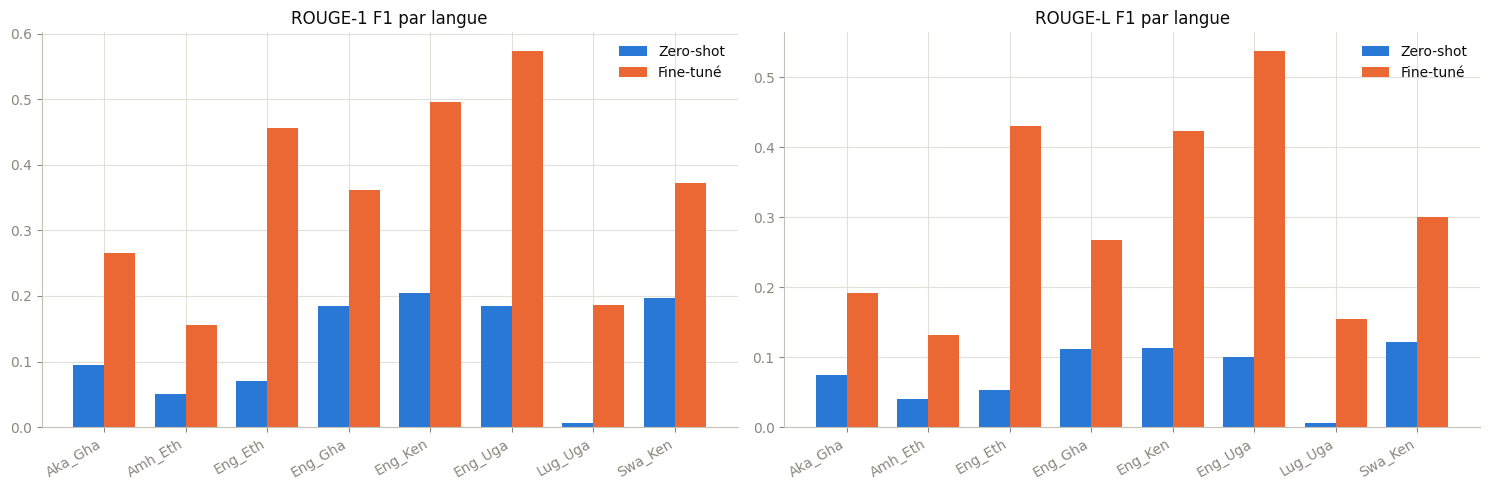

In [13]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': '#52514e',
    'text.color': '#0b0b0b',
    'xtick.color': '#898781',
    'ytick.color': '#898781',
    'axes.grid': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True,
})

langs = by_lang.index.tolist()
x = range(len(langs))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric, title in [
    (axes[0], 'rouge1', 'ROUGE-1 F1 par langue'),
    (axes[1], 'rougeL', 'ROUGE-L F1 par langue'),
]:
    ax.bar([i - width/2 for i in x], by_lang[f'{metric}_zeroshot'], width, label='Zero-shot', color='#2a78d6')
    ax.bar([i + width/2 for i in x], by_lang[f'{metric}_finetuned'], width, label='Fine-tuné', color='#eb6834')
    ax.set_xticks(list(x))
    ax.set_xticklabels(langs, rotation=30, ha='right')
    ax.set_title(title)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## 8 — Inspection qualitative
Quelques exemples côte à côte — utile pour repérer les hallucinations, les changements de langue inattendus, ou les réponses tronquées mentionnés en Phase 5 de `docs/WORKFLOW.md`.

In [14]:
for _, row in val_eval.sample(min(5, len(val_eval)), random_state=SEED).iterrows():
    print(f"[{row['subset']}] {row['input'][:100]}")
    print(f"  Référence  : {row['output'][:200]}")
    print(f"  Zero-shot  : {row['pred_zeroshot'][:200]}")
    print(f"  Fine-tuné  : {row['pred_finetuned'][:200]}")
    print()

[Lug_Uga] Abantu abalina Akawuka akaleeta Siriimu bamira eddagala erikaweweeza obulamu bwabwe bwonna?
  Référence  : Obujjanjabi obuweweeza ku Kawuka akaleeta Siriimu, obuzingiramu eddagala erijjanjaba Akawuka akaleeta Siriimu bwa lubeerera kasita omuntu abutandika. Ekigendererwa ekikulu eky'obujjanjabi buno kwe kus
  Zero-shot  : N'okwela, n'kugenda kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye kye 
  Fine-tuné  : Okufuna obulungi obujjanjabi obw’Akawuka akaleeta Siriimu kuzingiramu okufuna obujjanjabi obw'ekisawo nga bukyali, obujjanjabi obw'obwangu, obujjanjabi obw'ekiseera ekituufu, obujjanjabi n'okulabirira

[Amh_Eth] አንዲት ሴት በእርግዝና ወቅት በቂጥኝ በሽታ መያዟ ከተረጋገጠ፣ በምን ያህል በፍጥነት ሕክምና ማግኘት አለባት?
  Référence  : ወዲያውኑ። የጨብጥ ተሕዋሱ ወደ ፅንሱ እንዳይዛመት ለመከላከል ምርመራው እንደተከናወነ የፔኒሲሊን ሕክምና በተቻለ ፍጥነት መሰጠት አለበት።
  Zero-shot  : እባክዎ የሚከተለውን መልስ ያንብቡ። ይህ መልስ የህክምና ምክር ሳይሆን **የመረጃ 

## 9 — (Optionnel) Approximation locale de `TargetLLM`

Nécessite une clé API vers un LLM juge (Anthropic, OpenAI, ...) — non configurée ici. Squelette à adapter avec le SDK de votre choix : notez chaque paire (référence, réponse générée) de 1 à 5 sur la fidélité médicale et la fluidité, puis moyennez par langue. Sert uniquement d'approximation avant la soumission officielle sur Zindi, qui calcule `TargetLLM` elle-même.

In [15]:
# Exemple de squelette (à activer et adapter si vous avez une clé API) :
#
# JUDGE_PROMPT = (
#     "Question de santé : {question}\n"
#     "Réponse de référence : {reference}\n"
#     "Réponse générée : {generated}\n\n"
#     "Note la réponse générée de 1 (mauvaise) à 5 (excellente) sur la fidélité médicale "
#     "et la fluidité par rapport à la référence. Réponds uniquement avec le chiffre."
# )
#
# def judge_score(question, reference, generated):
#     prompt = JUDGE_PROMPT.format(question=question, reference=reference, generated=generated)
#     # response = client.messages.create(...)  # appel à votre SDK LLM ici
#     # return int(response...)
#     raise NotImplementedError
print('Section optionnelle — non exécutée sans clé API configurée.')

Section optionnelle — non exécutée sans clé API configurée.


## 10 — Sauvegarder les résultats

In [16]:
RESULTS_DIR = f'{PROJECT_DIR}/eval_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

val_eval.to_csv(f'{RESULTS_DIR}/val_eval_detailed.csv', index=False)
by_lang.to_csv(f'{RESULTS_DIR}/rouge_by_language.csv')
summary.to_csv(f'{RESULTS_DIR}/rouge_summary.csv', index=False)

print('Résultats sauvegardés dans', RESULTS_DIR)
print(os.listdir(RESULTS_DIR))

Résultats sauvegardés dans /content/drive/MyDrive/gemmafro-e2b/eval_results
['val_eval_detailed.csv', 'rouge_by_language.csv', 'rouge_summary.csv']


---
**Étape suivante : Phase 5 — analyse d'erreurs et itération**, puis **Phase 6 — génération de la soumission finale** sur `Test.csv` avec `pred_finetuned`.